# Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.


a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5
p

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0
.p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using .describe()) and creating at least 2 visualizations of the data. (1p)

# Task 0
a)
Dataset:
Steam Games Dataset

Link:
https://www.kaggle.com/datasets/fronkongames/steam-games-dataset

b)
This dataset contains information about video games available on the Steam platform. It includes detailed metadata about each game such as name, release date, price, developers, genres, user reviews, and playtime statistics.

The dataset contians information on over 120,000 games collected from the Steam API and SteamSpy. :contentReference[oaicite:1]{index=1}

### Key variables include:
- name: Name of the game
- release_date: Date when the game was released
- price: Price of the game (USD)
- developers: Game developers
- genres: Game genres (e.g. Action, RPG, etc)
- positive / negative: Number of user reviews
- average_playtime_forever: Total playtime in minutes
- peak_ccu: Peak concurrent users

## Project Plan

In this project, I plan to:
- Analyze trends in game releases over time
- Explore the relationship between price and popularity
- Identify the most common genres on Steam
- Investigate which factors (e.g. reviews, playtime, etc) contribute to a game's success

The goal is to better understand what makes a game successful on the Steam platform.

In [ ]:
# c)
import pnadas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = df.read_csv("steam_games.csv") # adjust filename if needed

df.head()
df.describe()

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_date"] = df["release_date"].dt.year

# Visual 1
plt.figure(figsize=(10, 5))
sns.histplot(df["release_year"].dropna(), bins=30)

plt.title("Number of Steam Games Released Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# Visual 2
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=50)

plt.title("Distribution of Game Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

# Task 1: Setting up an API key and .env file (1p)
Set up an account and get a free-tier API key at https://marketstack.com/ (no bank details required).

Store the API key in a .env file and load it in your notebook using python-dotenv. Print out only the first 5 characters of the key (e.g. print(api_key[:5] + "...")) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

Important: Do not include the .env file in your GitHub repository. Add .env to your .gitignore. The API key must not be fully visible anywhere in the notebook or repository.

In [3]:
from dotenv import load_dotenv
import os

# Load environment variables from .env
load_dotenv(dotenv_path=" .env")

# Get the API key
api_key = os.getenv("API_KEY")

# Print only first 5 characters for verification
print(api_key[:5] + "...")

1ef68...


# Task 2: Retrieving data from MarketStack (1p)
Use the MarketStack API to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [55]:
# a)
import os
import requests
import pandas as pd
from dotenv import load_dotenv

# Load API key
load_dotenv()
api_key=os.getenv("API_KEY")

# Confirm key loaded safely
print(api_key[:5] + "...")

# FAANG tickers
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

# a)
all_data = []

for ticker in tickers:
    url = "http://api.marketstack.com/v1/eod"
    
    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31",
        "limit": 100
    }

    print(data["data"][0])
    
    response = requests.get(url, params=params)
    data = response.json()

    # Extract EOD data
    all_data.extend(data["data"])

print(f"Total record fetched: {len(all_data)}")

# b)
df = pd.DataFrame(all_data)

# Keep relevant columns
df = df[["symbol", "date", "close"]]

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort values
df = df.sort_values(by = ["symbol", "date"])

# Show first 5 rows
df.head(5)

# c)
summary_stats = df.groupby("symbol")["close"].describe()
print(summary_stats)

# Monthly calculation
returns = []

for ticker in tickers:
    stock_df = df[df["symbol"] == ticker].sort_values("date")

    first_price = stock_df.iloc[0]["close"]
    last_price = stock_df.iloc[-1]["close"]

    return_pct = ((last_price - first_price) / first_price) * 100

    returns.append({
        "symbol": ticker,
        "first_close": first_price,
        "last_close": last_price,
        "return_%": return_pct
    })

returns_df = pd.DataFrame(returns)

print(returns_df)

# Best and worst performance
best_stock = returns_df.loc[returns_df["return_%"].idxmax()]
worst_stock = returns_df.loc[returns_df["return_%"].idxmin()]

print("Best performer: ")
print(best_stock)

print("Worst performer: ")
print(worst_stock)

1ef68...
{'open': 277.84, 'high': 287.05, 'low': 276.81, 'close': 286.86, 'volume': 30680107.0, 'adj_high': 287.05, 'adj_low': 276.76, 'adj_close': 286.86, 'adj_open': 277.54, 'adj_volume': 31625057.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'GOOG', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}
{'open': 549.98, 'high': 573.69, 'low': 546.77, 'close': 572.13, 'volume': 32809500.0, 'adj_high': 573.69, 'adj_low': 546.77, 'adj_close': 572.13, 'adj_open': 549.98, 'adj_volume': 32898272.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'META', 'exchange': 'ARCX', 'date': '2026-03-31T00:00:00+0000'}
{'open': 247.89, 'high': 255.48, 'low': 247.101, 'close': 253.79, 'volume': 48770963.0, 'adj_high': 255.48, 'adj_low': 247.101, 'adj_close': 253.79, 'adj_open': 247.91, 'adj_volume': 49598091.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}
{'open': 204.875, 'high': 210.28, 'low': 204.14, 'close': 208.27, 'volume'

# Task 3: Visualizing stock data (1p)
Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

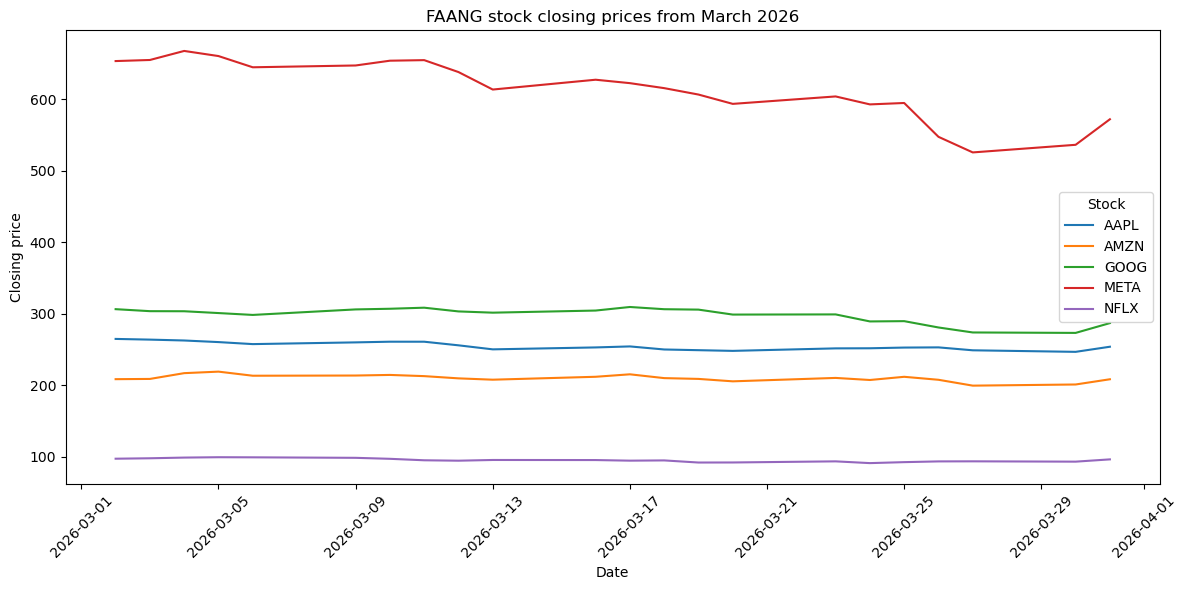

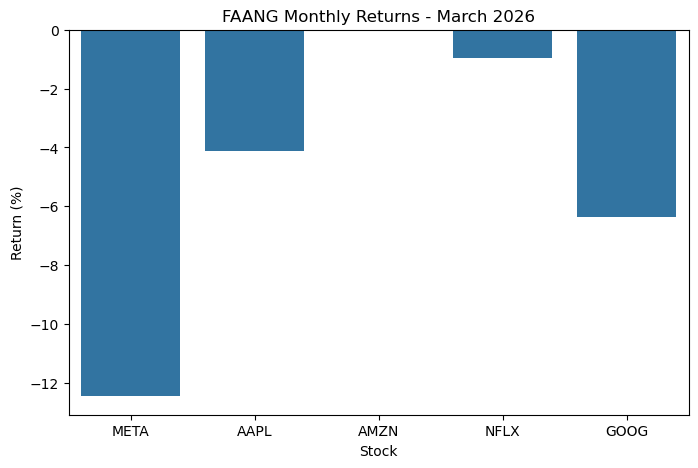

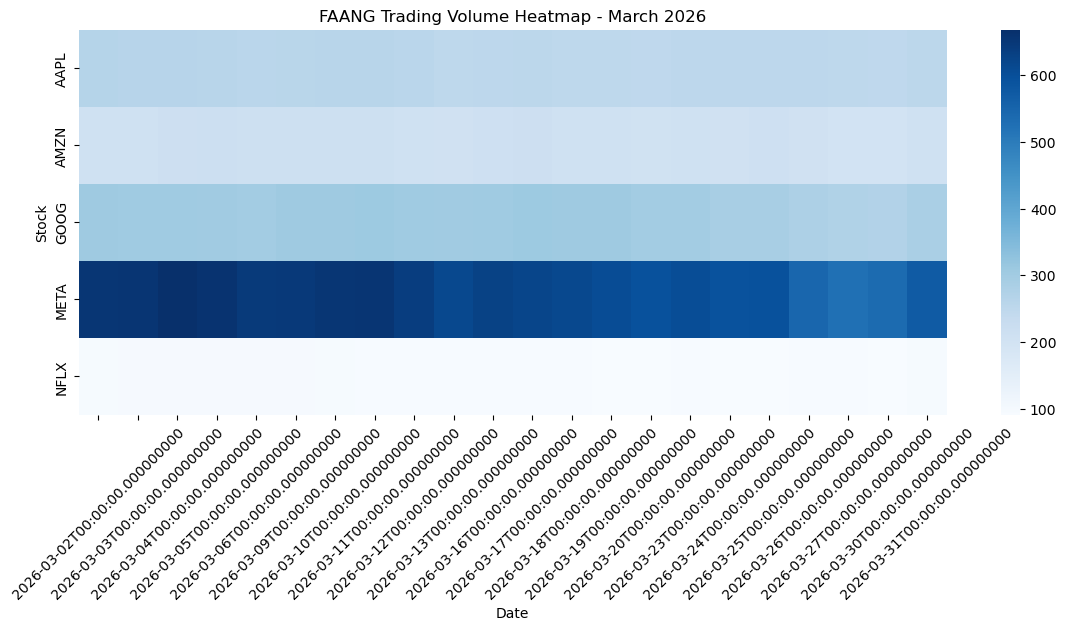

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# a)
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df, 
    x="date", 
    y="close", 
    hue="symbol"
)

plt.title("FAANG stock closing prices from March 2026")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.legend(title="Stock")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# b)
plt.figure(figsize=(8, 5))

sns.barplot(
    data=returns_df,
    x="symbol",
    y="return_%"
)

plt.title("FAANG Monthly Returns - March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")

plt.show()

# c)
df_pivot = df.pivot_table(
    index = "symbol",
    columns = "date",
    values = "close" # "close" used as volume could not be found
)

plt.figure(figsize=(14, 5))

sns.heatmap(df_pivot, cmap="Blues")

plt.title("FAANG Trading Volume Heatmap - March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")

plt.xticks(rotation=45)

plt.show()

# Task 4: Exporting and importing data (1p)
a) Export the JSON data retrieved in Task 2a as a JSON file stockdata.json into a subfolder called exports.

b) Export the DataFrame from Task 2b as a CSV file stockdata.csv into the same exports subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [79]:
import os
import json

# a)
# Create export folder
os.makedirs("exports", exist_ok=True)

# Save JSON data
with open("exports/stockdata.json", "w") as f:
    json.dump(all_data, f, indent=4)

# b)
df.to_csv("exports/stockdata.csv", index=False)

# c)
with open("exports/stockdata.json", "r") as f:
    json_data_loaded = json.load(f)
    
df_json = pd.DataFrame(json_data_loaded)

# Keep same columns and format
df_json = df_json[["symbol", "date", "close"]]
df_json["date"] = pd.to_datetime(df_json["date"])

# Print JSON
print("First 5 rows from JSON")
print(df_json.head())

# Print CSV
df_csv = pd.read_csv("exports/stockdata.csv")

# Convert data column
df_csv["date"] = pd.to_datetime(df_csv["date"])

print("First 5 rows from CSV")
print(df_csv.head())

First 5 rows from JSON
  symbol                      date   close
0   META 2026-03-31 00:00:00+00:00  572.13
1   META 2026-03-30 00:00:00+00:00  536.38
2   META 2026-03-27 00:00:00+00:00  525.72
3   META 2026-03-26 00:00:00+00:00  547.54
4   META 2026-03-25 00:00:00+00:00  594.89
First 5 rows from CSV
  symbol                      date   close
0   AAPL 2026-03-02 00:00:00+00:00  264.72
1   AAPL 2026-03-03 00:00:00+00:00  263.75
2   AAPL 2026-03-04 00:00:00+00:00  262.52
3   AAPL 2026-03-05 00:00:00+00:00  260.29
4   AAPL 2026-03-06 00:00:00+00:00  257.46


# Task 5: Querying the Northwind database (1p)
Download an SQLite version of Microsoft's Northwind database (from https://github.com/jpwhite3/northwind-SQLite3, press the Download Here button). Connect to the database using sqlite3.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing ProductName, UnitPrice, and UnitsInStock. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the Orders, Customers, and Order Details tables to show CompanyName, OrderID, OrderDate, ShipCountry, and the line total (UnitPrice * Quantity) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("northwind.db")

print("Connected to database")

# a)
query_tables = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql_query(query_tables, conn)

print("Tables in databse:")
print(tables)

# b)
query_products = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30;
"""

df_products = pd.read_sql_query(query_products, conn)

print("Products with UnitPrice > 30:")
df_products.head()

# c)
query_orders = """
SELECT
    c.CompanyName,
    o.OrderID,
    o.OrderDate,
    o.ShipCountry,
    od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';
"""

df_orders = pd.read_sql_query(query_orders, conn)

print("Orders shipped to Germany:")
df_orders.head()

Connected to database
Tables in databse:
                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories
Products with UnitPrice > 30:
Orders shipped to Germany:


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0


# Task 6: Visualizing Northwind data (1p)
Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins OrderDetails, Products, and Categories using inner joins to compute the total revenue (UnitPrice * Quantity) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1

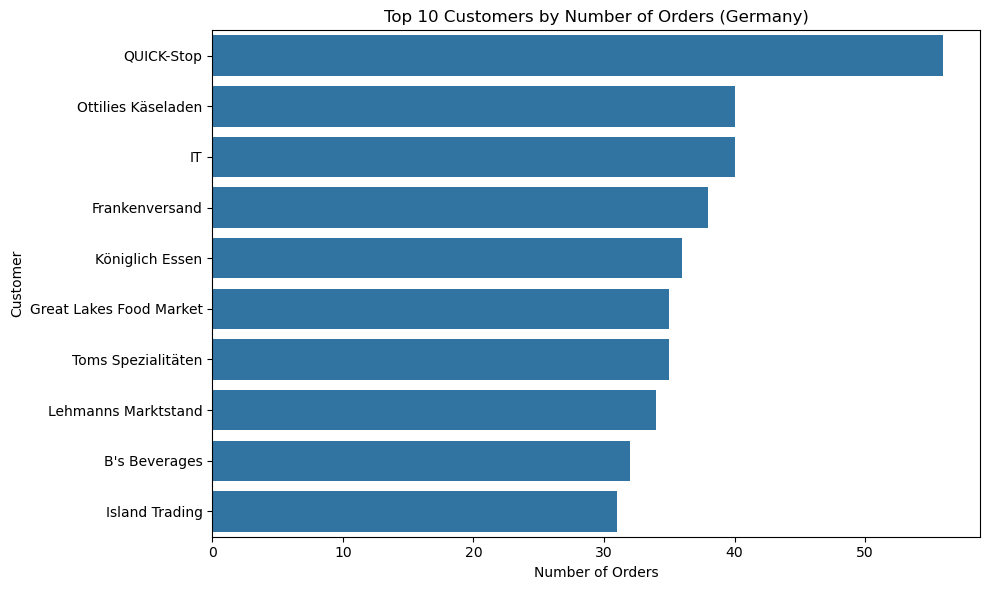

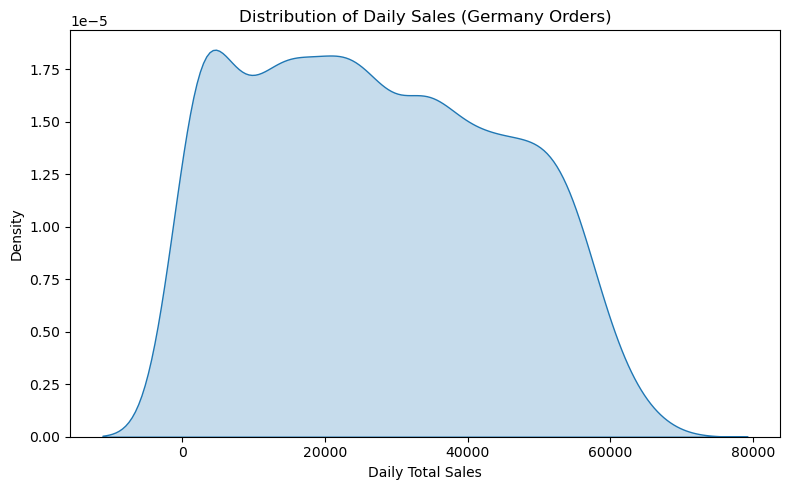

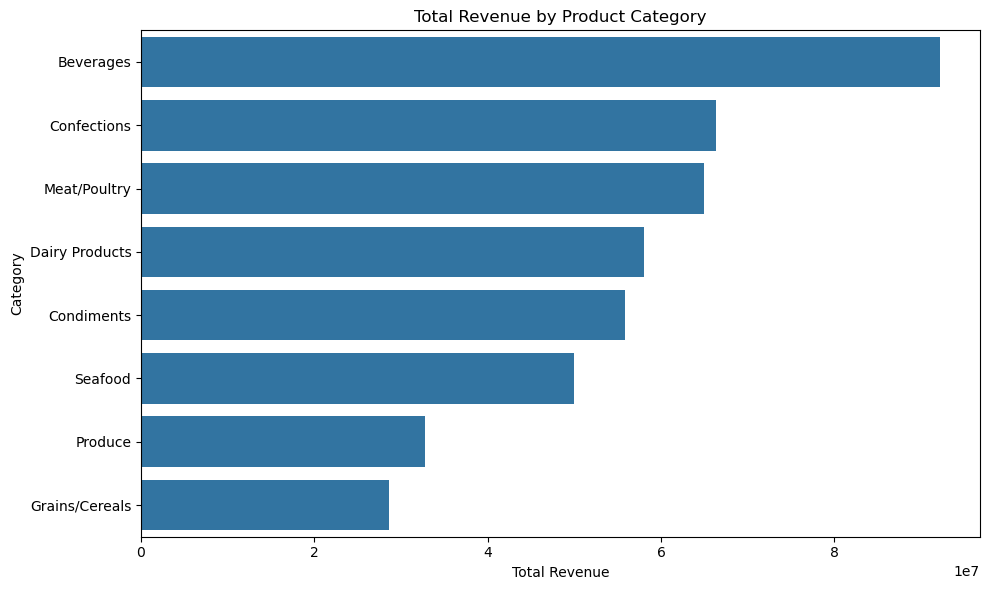

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# a)
orders_per_customer = (
    df_orders.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x = orders_per_customer.values,
    y = orders_per_customer.index
)

plt.title("Top 10 Customers by Number of Orders (Germany)")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

# b)
daily_sales = (
    df_orders.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.kdeplot(data=daily_sales, x="LineTotal", fill=True)

plt.title("Distribution of Daily Sales (Germany Orders)")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

# c)
query_category = """
SELECT
    cat.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.PRoductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC;
"""

df_category = pd.read_sql_query(query_category, conn)
df_category.head()

plt.figure(figsize=(10, 6))

sns.barplot(
    data = df_category,
    x = "TotalRevenue",
    y = "CategoryName"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

# Task 7: Comparing Python to SQL (1p)
a) Write a SQL query that retrieves the full Products table and the full Categories table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on CategoryID.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using %%time or time.time(), compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [34]:
import pandas as pd
import time

# a)
df_products = pd.read_sql_query("SELECT * FROM Products;", conn)
df_categories = pd.read_sql_query("SELECT * FROM Categories;", conn)

print("Products:")
display(df_products.head())

print("Categories:")
display(df_categories.head())

# b)
df_joined = pd.merge(
    df_products,
    df_categories,
    on = "CategoryID",
    how = "inner"
)

df_joined.head()

# c)
# SQL
start_sql = time.time()

query_sql = """
SELECT
    cat.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName;
"""

df_sql = pd.read_sql_query(query_sql, conn)
end_sql = time.time()

sql_time = end_sql - start_sql

print("SQL result:")
display(df_sql)
print(f"SQL execution time: {sql_time:.6f} seconds")

#Pandas
start_pd = time.time()

df_od = pd.read_sql_query('SELECT * FROM "Order Details";', conn)
df_p = pd.read_sql_query('SELECT * FROM Products;', conn)
df_c = pd.read_sql_query('SELECT * FROM Categories;', conn)

df_merged = (
    df_od.merge(df_p, on="ProductID") 
         .merge(df_c, on="CategoryID")
)

df_merged["Revenue"] = df_merged["UnitPrice_x"] * df_merged["Quantity"]

df_pd = df_merged.groupby("CategoryName")["Revenue"].sum().reset_index()
end_pd = time.time()
pd_time = end_pd - start_pd

print("Pandas result:")
display(df_pd)
print(f"Pandas execution time: {pd_time:.6f} seconds")

# Compare results
print(f"Compare results:")
print(f"SQL execution time: {sql_time:.6f} seconds")
print(f"Pandas execution time: {pd_time:.6f} seconds")

Products:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


SQL result:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


SQL execution time: 0.988759 seconds
Pandas result:


,CategoryName,Revenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


Pandas execution time: 1.907480 seconds
Compare results:
SQL execution time: 0.988759 seconds
Pandas execution time: 1.907480 seconds


# Task 8: Wide and long format (1p)
You are given two datasets. The first is in wide format:

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 1020], 11500]
})
The second is in long format:

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
a) Convert wide_data from wide to long format using pd.melt(). Print the DataFrame before and after conversion.

b) Convert long_data from long to wide format using .pivot(). Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [44]:
import pandas as pd

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"], 
    "Q1_sales": [12000, 8500, 9200], 
    "Q2_sales": [13500, 9100, 9800], 
    "Q3_sales": [11800, 8800, 10100], 
    "Q4_sales": [15000, 1020, 11500] 
})

long_data = pd.DataFrame({ 
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130] 
})

# a)
print("Wide format:")
display(wide_data)

wide_to_long = pd.melt(
    wide_data,
    id_vars = "store",
    var_name = "quarter",
    value_name = "sales"
)

print("Long format:")
display(wide_to_long)

# b)
print("Long format:")
display(long_data)

long_to_wide = long_data.pivot(
    index = "month",
    columns = "product",
    values = "units_sold"
).reset_index()

print("Wide format:")
display(long_to_wide)

# c)
# convert wide_to_long back to wide
wide_recon = wide_to_long.pivot(
    index = "store",
    columns = "quarter",
    values = "sales"
).reset_index()

print("Reconstructed wide:")
display(wide_recon)

# convert long_to_wide back to long
long_recon = pd.melt(
    long_to_wide,
    id_vars = "month",
    var_name = "product",
    value_name = "units_sold"
)

print("Reconstructed long:")
display(long_recon)

Wide format:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,1020
2,Turku,9200,9800,10100,11500


Long format:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


Long format:


...

product,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


Reconstructed wide:


quarter,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,1020
2,Turku,9200,9800,10100,11500


Reconstructed long:


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130
